# EDA — NVDA MBP-1

Exploratory analysis of the order-update stream.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_book

df = load_book("data/nvda_mbp1_2026-06-01.parquet")
df.shape

(3336062, 19)

## Order updates per minute

Each row is one order-book update (add / cancel / trade). Resample the
event timestamps to 1-minute bins and count.

In [2]:
# Count rows (order updates) in each 1-minute bin.
updates_per_min = (
    df.set_index("ts_event")
      .resample("1min")
      .size()
)

print(f"average updates per minute: {updates_per_min.mean()}")
updates_per_min

average updates per minute: 8554.005128205128


ts_event
2026-06-01 09:30:00-04:00    30956
2026-06-01 09:31:00-04:00    57054
2026-06-01 09:32:00-04:00    30600
2026-06-01 09:33:00-04:00    35719
2026-06-01 09:34:00-04:00    26124
                             ...  
2026-06-01 15:55:00-04:00    12660
2026-06-01 15:56:00-04:00    12113
2026-06-01 15:57:00-04:00    15348
2026-06-01 15:58:00-04:00    14014
2026-06-01 15:59:00-04:00    27829
Freq: min, Length: 390, dtype: int64

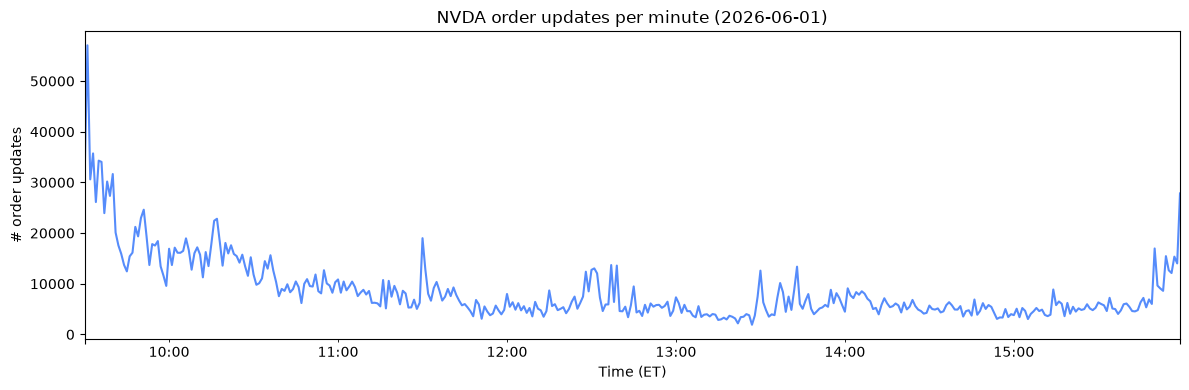

In [3]:
# Plot it.
ax = updates_per_min.plot(figsize=(12, 4), title="NVDA order updates per minute (2026-06-01)")
ax.set_xlabel("Time (ET)")
ax.set_ylabel("# order updates")
plt.tight_layout()
plt.show()

## Factor visualization

Compute the five factors on the loaded book and inspect their behaviour
over the session and their distributions.

In [4]:
from factors import (
    obi_ratio,
    net_liquidity_flow,
    trend_ratio,
    change_in_spread,
    volume_weighted_mid_deviation,
)

factors = pd.DataFrame({"ts_event": df["ts_event"]})
factors["obi_ratio"] = obi_ratio(df)
factors["net_liquidity_flow"] = net_liquidity_flow(df, look_back_ticks=100)
factors["trend_ratio"] = trend_ratio(df, look_back_ticks=100)
factors["change_in_spread"] = change_in_spread(df, look_back_ticks=100)
factors["vwmd"] = volume_weighted_mid_deviation(df, look_back_trades=100)
factors = factors.set_index("ts_event")

factor_cols = ["obi_ratio", "net_liquidity_flow", "trend_ratio", "change_in_spread", "vwmd"]
factors[factor_cols].describe()

,obi_ratio,net_liquidity_flow,trend_ratio,change_in_spread,vwmd
count,3.336062e+06,3.335963e+06,3.323532e+06,3.335963e+06,3.335736e+06
mean,6.722914e-03,-1.392986e-01,8.954207e-04,-9.582840e-07,5.037431e-04
std,5.558652e-01,1.873919e-01,3.551944e-01,8.749184e-03,3.654072e-02
min,-9.999716e-01,-1.000000e+00,-1.000000e+00,-2.445000e-01,-7.374481e-01
25%,-4.492754e-01,-2.338345e-01,-2.054795e-01,-4.800000e-03,-2.078293e-02
50%,9.708738e-03,-1.334552e-01,0.000000e+00,4.548445e-15,5.529412e-04
75%,4.683544e-01,-3.722504e-02,2.173913e-01,4.500000e-03,2.185821e-02
max,9.999465e-01,1.000000e+00,1.000000e+00,3.841000e-01,2.607920e-01


### Time series (1-minute mean)

Each factor is computed per tick (~3.3M rows); we resample to the 1-minute
mean so the session-level behaviour is visible.

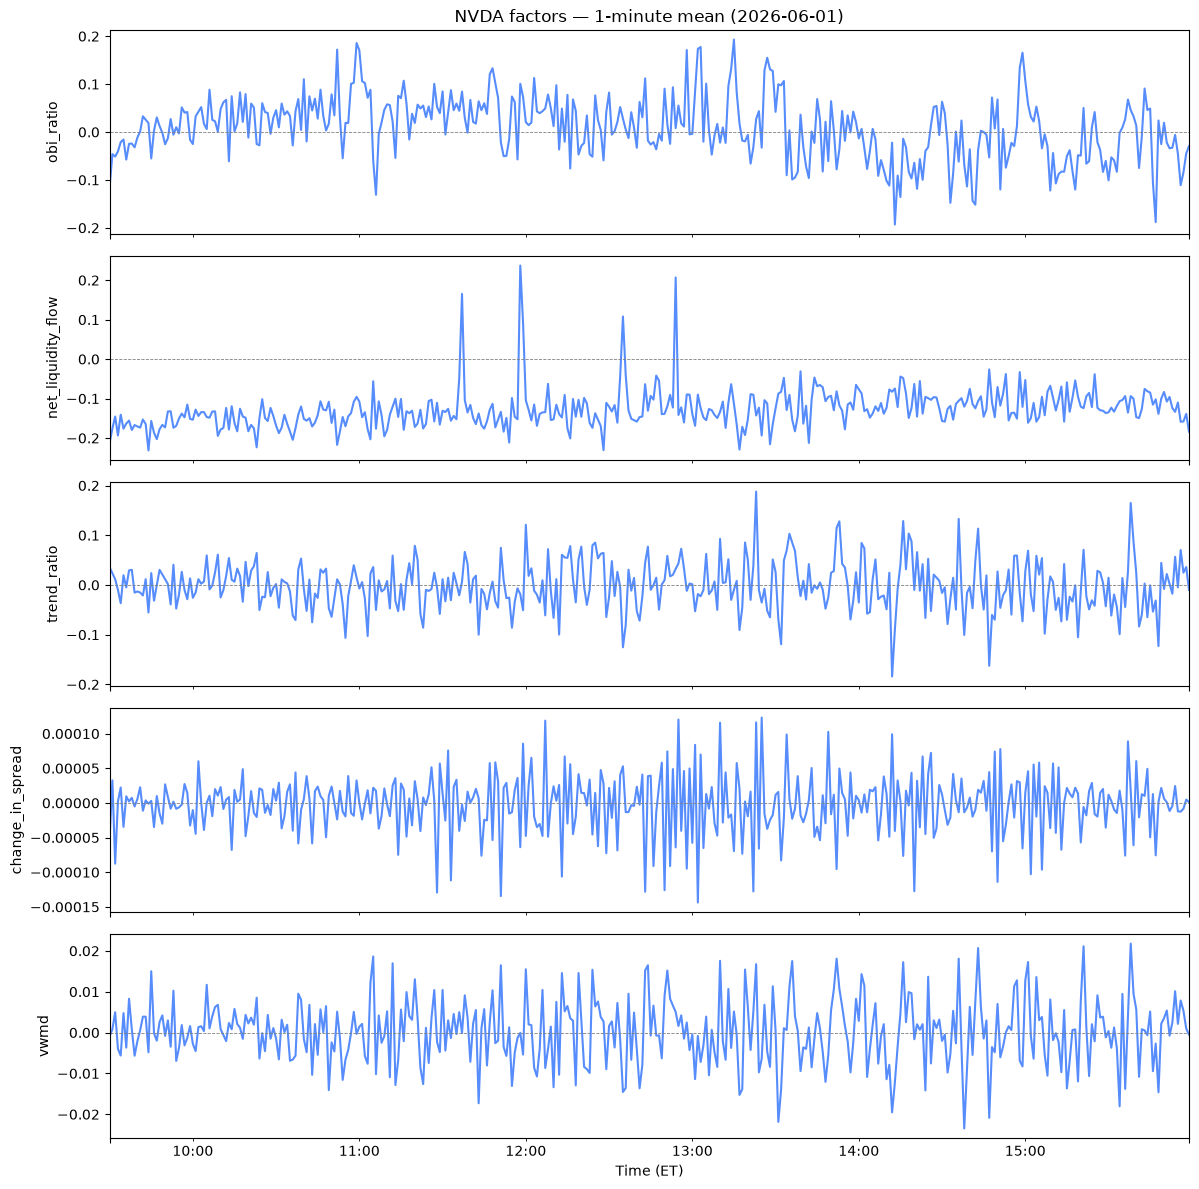

In [5]:
per_min = factors[factor_cols].resample("1min").mean()

fig, axes = plt.subplots(len(factor_cols), 1, figsize=(12, 12), sharex=True)
for ax, col in zip(axes, factor_cols):
    per_min[col].plot(ax=ax)
    ax.set_ylabel(col)
    ax.axhline(0, color="grey", lw=0.6, ls="--")
axes[0].set_title("NVDA factors — 1-minute mean (2026-06-01)")
axes[-1].set_xlabel("Time (ET)")
plt.tight_layout()
plt.show()

### Distributions

Per-tick distribution of each factor (NaN warm-up rows dropped automatically).

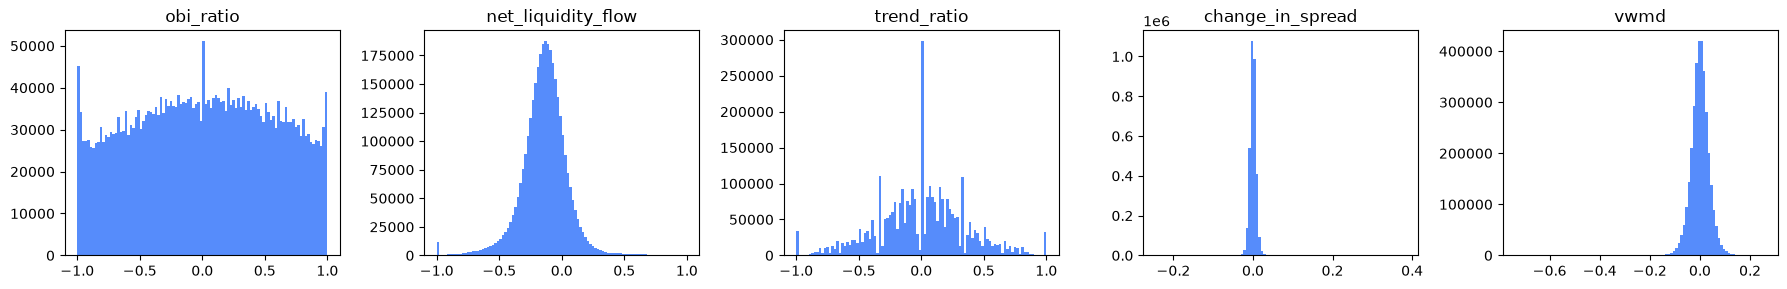

In [6]:
fig, axes = plt.subplots(1, len(factor_cols), figsize=(18, 3))
for ax, col in zip(axes, factor_cols):
    factors[col].plot.hist(bins=100, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()